         x1        x2  etiqueta
0 -0.008864  0.113353         0
1  0.242456 -0.075897         0
2 -0.014196 -0.070382         0
3 -0.165579 -0.143002         0
4  0.202125  0.327485         0


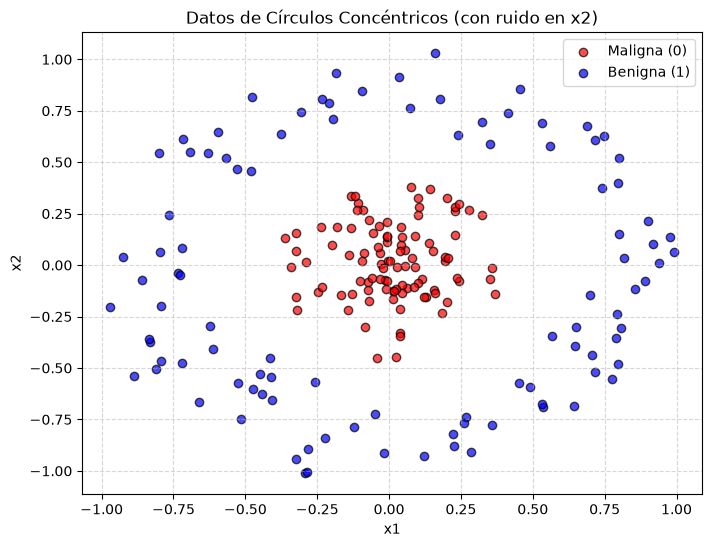

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Configurar semilla para reproducibilidad
np.random.seed(42)

# 2. Definir parámetros
n_samples_per_class = 100  # 100 para malignas (0) y 100 para benignas (1)
n_total = n_samples_per_class * 2

# 3. Generar círculos concéntricos
# Clase 0: Círculo interno (Malignas)
theta_0 = np.random.uniform(0, 2 * np.pi, n_samples_per_class)
r_0 = np.random.uniform(0, 0.4, n_samples_per_class)  # Radio interno pequeño
x1_0 = r_0 * np.cos(theta_0)
x2_0 = r_0 * np.sin(theta_0)
y_0 = np.zeros(n_samples_per_class)

# Clase 1: Círculo externo (Benignas)
theta_1 = np.random.uniform(0, 2 * np.pi, n_samples_per_class)
r_1 = np.random.uniform(0.7, 1.0, n_samples_per_class)  # Radio externo grande
x1_1 = r_1 * np.cos(theta_1)
x2_1 = r_1 * np.sin(theta_1)
y_1 = np.ones(n_samples_per_class)

# 4. Combinar los datos
x1 = np.concatenate([x1_0, x1_1])
x2 = np.concatenate([x2_0, x2_1])
etiqueta = np.concatenate([y_0, y_1])

# 5. Agregar ruido al valor de x2
ruido = np.random.normal(0, 0.08, n_total)  # Ruido gaussiano con media 0 y desviación estándar 0.08
x2 = x2 + ruido

# 6. Crear un DataFrame de Pandas
df_celulas = pd.DataFrame({
    'x1': x1,
    'x2': x2,
    'etiqueta': etiqueta.astype(int)
})

# Mostrar las primeras 5 filas del dataset
print(df_celulas.head())

# 7. (Opcional) Visualizar los datos generados
plt.figure(figsize=(8, 6))
plt.scatter(df_celulas[df_celulas['etiqueta'] == 0]['x1'], 
            df_celulas[df_celulas['etiqueta'] == 0]['x2'], 
            color='red', label='Maligna (0)', alpha=0.7, edgecolors='k')
plt.scatter(df_celulas[df_celulas['etiqueta'] == 1]['x1'], 
            df_celulas[df_celulas['etiqueta'] == 1]['x2'], 
            color='blue', label='Benigna (1)', alpha=0.7, edgecolors='k')

plt.title('Datos de Círculos Concéntricos (con ruido en x2)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Cantidad total de datos: 200
Datos usados para entrenar: 150
Datos usados para probar: 50
Exactitud en entrenamiento: 1.000
Exactitud en prueba: 1.000

Reporte de clasificacion:
              precision    recall  f1-score   support

 Maligna (0)       1.00      1.00      1.00        25
 Benigna (1)       1.00      1.00      1.00        25

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



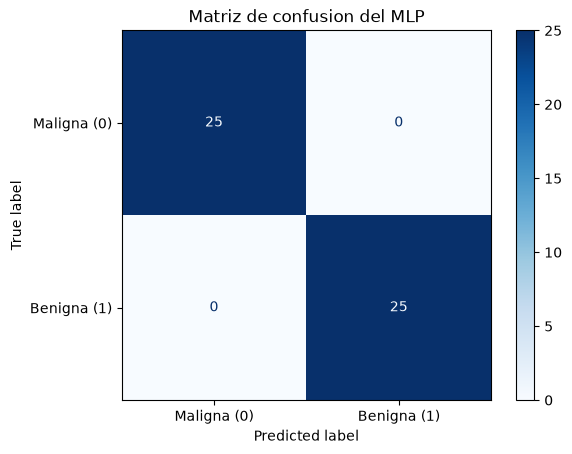

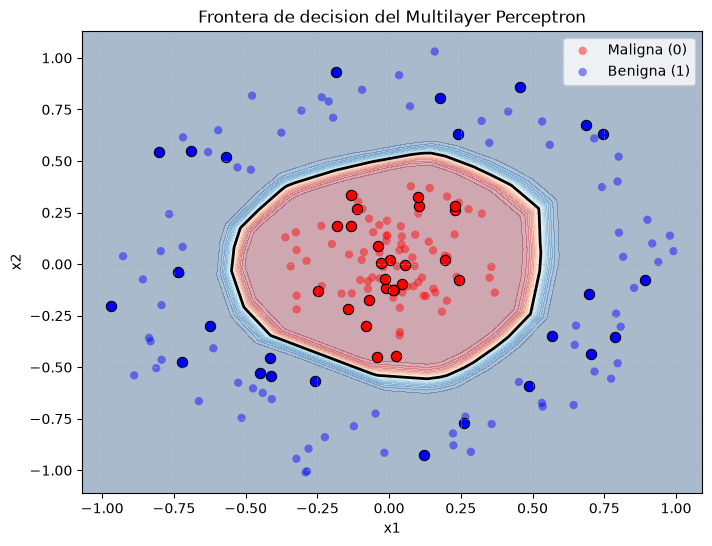

Nueva celula: Maligna
Probabilidad maligna: 1.000
Probabilidad benigna: 0.000


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# Separar variables predictoras y objetivo
X = df_celulas[['x1', 'x2']]
y = df_celulas['etiqueta']

# Mantener la misma proporcion de clases en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# El escalado es importante para que ambas variables tengan una influencia comparable
modelo_mlp = Pipeline([
    ('escalador', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(20, 20),
        activation='relu',
        solver='lbfgs',
        max_iter=2000,
        random_state=42
    ))
])

# Entrenar la red neuronal y generar predicciones
modelo_mlp.fit(X_train, y_train)
y_pred = modelo_mlp.predict(X_test)

print(f'Cantidad total de datos: {len(X)}')
print(f'Datos usados para entrenar: {len(X_train)}')
print(f'Datos usados para probar: {len(X_test)}')
print(f'Exactitud en entrenamiento: {modelo_mlp.score(X_train, y_train):.3f}')
print(f'Exactitud en prueba: {accuracy_score(y_test, y_pred):.3f}')
print('\nReporte de clasificacion:')
print(classification_report(y_test, y_pred, target_names=['Maligna (0)', 'Benigna (1)']))

# Matriz de confusion
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Maligna (0)', 'Benigna (1)'],
    cmap='Blues'
)
plt.title('Matriz de confusion del MLP')
plt.show()

# Frontera de decision aprendida por el MLP
x1_min, x1_max = X['x1'].min() - 0.1, X['x1'].max() + 0.1
x2_min, x2_max = X['x2'].min() - 0.1, X['x2'].max() + 0.1
malla_x1, malla_x2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 300),
    np.linspace(x2_min, x2_max, 300)
)
puntos_malla = pd.DataFrame({
    'x1': malla_x1.ravel(),
    'x2': malla_x2.ravel()
})
probabilidad_benigna = modelo_mlp.predict_proba(puntos_malla)[:, 1]
probabilidad_benigna = probabilidad_benigna.reshape(malla_x1.shape)

plt.figure(figsize=(8, 6))
plt.contourf(malla_x1, malla_x2, probabilidad_benigna, levels=30, cmap='RdBu', alpha=0.35)
plt.contour(malla_x1, malla_x2, probabilidad_benigna, levels=[0.5], colors='black', linewidths=2)

# Mostrar los 200 datos; los puntos de prueba se resaltan con borde negro
plt.scatter(X.loc[y == 0, 'x1'], X.loc[y == 0, 'x2'], c='red', alpha=0.45, label='Maligna (0)', edgecolors='none')
plt.scatter(X.loc[y == 1, 'x1'], X.loc[y == 1, 'x2'], c='blue', alpha=0.45, label='Benigna (1)', edgecolors='none')
plt.scatter(X_test.loc[y_test == 0, 'x1'], X_test.loc[y_test == 0, 'x2'], c='red', edgecolors='black', linewidths=0.8, s=55)
plt.scatter(X_test.loc[y_test == 1, 'x1'], X_test.loc[y_test == 1, 'x2'], c='blue', edgecolors='black', linewidths=0.8, s=55)

plt.title('Frontera de decision del Multilayer Perceptron')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

# Ejemplo de prediccion para una nueva celula
nueva_celula = pd.DataFrame({'x1': [0.05], 'x2': [0.10]})
prediccion = modelo_mlp.predict(nueva_celula)[0]
probabilidades = modelo_mlp.predict_proba(nueva_celula)[0]
clase_predicha = 'Benigna' if prediccion == 1 else 'Maligna'
print(f'Nueva celula: {clase_predicha}')
print(f'Probabilidad maligna: {probabilidades[0]:.3f}')
print(f'Probabilidad benigna: {probabilidades[1]:.3f}')